# Imports

In [1]:
import os
from pathlib import Path

In [2]:
import pandas as pd

In [3]:
from backtester import BackTester

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
import pyfolio as pf
from pyfolio.plotting import plot_rolling_returns,plot_rolling_sharpe
from pyfolio.timeseries import forecast_cone_bootstrap

In [6]:
import warnings
warnings.filterwarnings("ignore")

In [7]:
data_store="../Prepared_Data_Store"

# BackTesting

## Trading Strategy-I:

### Here we will long the top returns and short the bottom returns values at a particular day as predicted by our Model-4

In [8]:
trading_strategy={
    "strategy":"returns_based",
    "values":{}
}

In [9]:
backtester=BackTester(
    n_longs=20,
    n_shorts=20,
    min_positions=10,
    capital_base=1e6,
    commission_cost=0.00075,
    commission_min_trade_cost=0.01,
    slippage_spread=0.0,
    predictions_file=os.path.join(data_store,"factors.csv"),
    predictions_column_name="Model4_Factors",
    trading_strategy=trading_strategy
)

In [10]:
results=backtester.run_backtesting()

INFO: Model predictions loaded...
INFO: Missing Date Values added in Model Predictions...
INFO: Model Data Loader created...
INFO: Backtesting started for trading strategy-I...
INFO: Backtesting completed...


### Performance analysis using Pyfolio

#### Loading Benchmark Data

In [11]:
benchmark_data=pd.read_csv(
    os.path.join(data_store,"sp500_data.csv"),
    parse_dates=["date"],
    index_col=["date"]
)

In [12]:
benchmark_data=benchmark_data.sp500_returns.tz_localize("UTC")

#### Extracting information from Zipline Results

In [13]:
returns,positions,transactions=pf.utils.extract_rets_pos_txn_from_zipline(results)

#### Plotting Rolling Returns and Sharpe Ratio

In [14]:
LIVE_DATE="2016-02-24"

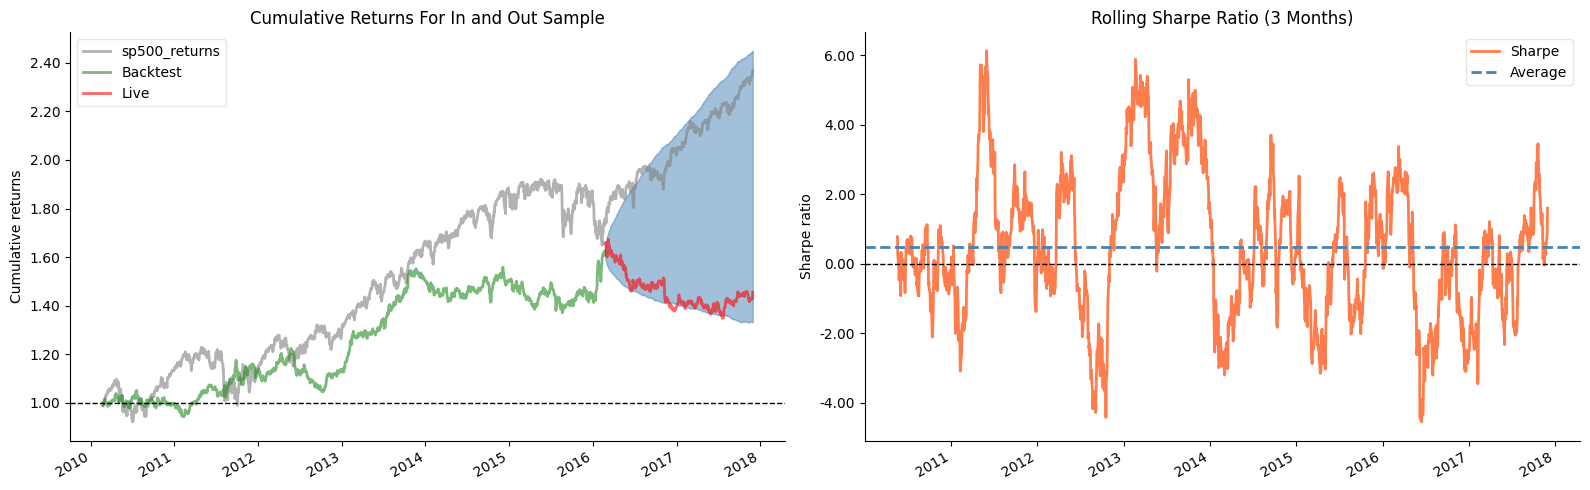

In [15]:
fig,axes=plt.subplots(ncols=2,figsize=(16,5))

plot_rolling_returns(
    returns,
    factor_returns=benchmark_data,
    live_start_date=LIVE_DATE,
    logy=False,
    cone_std=2,
    legend_loc="best",
    volatility_match=False,
    cone_function=forecast_cone_bootstrap,
    ax=axes[0]
)

plot_rolling_sharpe(returns,rolling_window=63,ax=axes[1])

axes[0].set_title("Cumulative Returns For In and Out Sample")
axes[1].set_title("Rolling Sharpe Ratio (3 Months)")

sns.despine()
fig.tight_layout()

#### Full Tear Sheet

Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,19.37,2016-03-09,2017-07-21,NaT,NaN
1,14.55,2012-05-24,2012-10-11,2013-02-05,184
2,12.05,2014-12-05,2015-08-21,2016-01-25,297
3,10.25,2010-07-20,2011-02-11,2011-05-06,209
4,8.87,2013-11-21,2014-10-13,2014-12-04,271


Stress Events,mean,min,max
US downgrade/European Debt Crisis,0.22%,-3.00%,2.53%
Fukushima,0.10%,-0.61%,1.17%
EZB IR Event,-0.10%,-1.25%,1.14%
Flash Crash,0.19%,-0.10%,0.55%
Apr14,-0.03%,-1.44%,0.70%
Oct14,0.05%,-1.90%,2.35%
Fall2015,0.05%,-1.68%,1.15%
Recovery,0.02%,-3.08%,2.86%
New Normal,0.02%,-3.59%,4.26%


Top 10 long positions of all time,max
sid,
NFLX,43.05%
WTW,31.77%
URI,22.69%
AZO,20.60%
VRTX,20.57%
MDT,20.51%
DPZ,20.26%
FICO,20.06%
APD,19.88%


Top 10 short positions of all time,max
sid,
NFLX,-37.45%
URI,-28.18%
WTW,-26.52%
MNST,-24.99%
APD,-24.11%
WMB,-21.78%
ROST,-20.64%
INCY,-20.55%
SYK,-20.35%


Top 10 positions of all time,max
sid,
NFLX,43.05%
WTW,31.77%
URI,28.18%
MNST,24.99%
APD,24.11%
WMB,21.78%
ROST,20.64%
AZO,20.60%
VRTX,20.57%


...

PnL stats,All trades,Short trades,Long trades
Total profit,$687244.99,$-1013861.40,$1701106.39
Gross profit,$26127175.00,$12036793.34,$14090381.65
Gross loss,$-25439930.00,$-13050654.74,$-12389275.26
Profit factor,$1.03,$0.92,$1.14
Avg. trade net profit,$9.07,$-27.71,$43.41
Avg. winning trade,$688.46,$683.13,$693.08
Avg. losing trade,$-683.13,$-698.57,$-667.60
Ratio Avg. Win:Avg. Loss,$1.01,$0.98,$1.04
Largest winning trade,$73558.32,$73558.32,$24844.82
Largest losing trade,$-33871.68,$-20922.28,$-33871.68


Duration stats,All trades,Short trades,Long trades
Avg duration,1 days 12:50:06.777442001,1 days 12:13:25.301639792,1 days 13:24:22.304634071
Median duration,1 days 00:00:00,1 days 00:00:00,1 days 00:00:00
Longest duration,164 days 01:00:00,164 days 01:00:00,99 days 23:00:00
Shortest duration,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00


Return stats,All trades,Short trades,Long trades
Avg returns all round_trips,0.00%,-0.00%,0.00%
Avg returns winning,0.05%,0.05%,0.05%
Avg returns losing,-0.05%,-0.05%,-0.05%
Median returns all round_trips,0.00%,-0.00%,0.00%
Median returns winning,0.03%,0.03%,0.03%
Median returns losing,-0.03%,-0.03%,-0.03%
Largest winning trade,4.90%,4.90%,2.01%
Largest losing trade,-2.34%,-1.66%,-2.34%


Symbol stats,A,ACGL,ACN,ADI,ADM,ADP,ADSK,AEE,AEP,AES,AFL,AIG,AIZ,AJG,ALB,ALGN,ALL,AMAT,AMD,AME,AMGN,AMP,AMT,AON,AOS,APA,APD,APH,ARE,ATO,AVB,AVGO,AVY,AWK,AXP,AZO,BA,BAC,BAX,BBY,BDX,BEN,BG,BIIB,BK,BLDR,BLK,BMY,BR,BRO,BSX,BXP,C,CAG,CAH,CAT,CB,CCI,CCL,CDNS,CF,CHD,CHRW,CI,CINF,CL,CLX,CME,CMG,CMI,CMS,CNC,CNP,COF,COO,COP,CPB,CPRT,CPT,CRL,CRM,CSCO,CSGP,CSX,CTAS,CTSH,CVS,CVX,D,DAL,DE,DECK,DG,DGX,DHI,DHR,DIS,DLR,DLTR,DOV,DPZ,DRI,DTE,DUK,DVA,DVN,DXCM,EA,EBAY,ECL,ED,EFX,EIX,EL,EMN,EMR,EOG,EQIX,EQR,EQT,ERIE,ES,ESS,ETN,ETR,EW,EXC,EXPD,EXPE,EXR,F,FCX,FDS,FDX,FE,FFIV,FICO,FIS,FITB,FOX,FOXA,FRT,FTNT,GD,GE,GILD,GIS,GLW,GOOGL,GPC,GPN,GRMN,GS,GWW,HAL,HAS,HBAN,HD,HIG,HOLX,HON,HPQ,HRL,HSIC,HST,HSY,HUM,IBM,ICE,IDXX,IEX,IFF,INCY,INTU,IP,IPG,IR,IRM,ISRG,IT,ITW,IVZ,JBHT,JBL,JCI,JKHY,JNJ,JPM,K,KEY,KIM,KLAC,KMB,KMX,KO,KR,L,LDOS,LEN,LH,LII,LKQ,LLY,LMT,LNT,LRCX,LUV,LVS,LYV,MA,MAA,MAR,MAS,MCD,MCHP,MCK,MCO,MDLZ,MDT,MET,MGM,MHK,MKC,MKTX,MLM,MMC,MNST,MO,MOH,MOS,MPWR,MRK,MS,MSCI,MSFT,MSI,MTB,MTD,MU,NDAQ,NDSN,NEE,NEM,NFLX,NI,NKE,NOC,NRG,NSC,NTAP,NTRS,NUE,NVDA,NVR,O,ODFL,OKE,OMC,ORCL,ORLY,OXY,PAYX,PCAR,PCG,PEG,PEP,PFE,PFG,PG,PGR,PH,PHM,PKG,PLD,PM,PNC,PNR,PNW,PODD,POOL,PPG,PPL,PRU,PSA,PWR,RCL,REG,REGN,RF,RJF,RL,RMD,ROK,ROL,ROP,ROST,RSG,SBAC,SBUX,SCHW,SHW,SJM,SLB,SMCI,SNA,SNPS,SO,SPG,SRE,STE,STLD,STT,STX,STZ,SWK,SWKS,SYK,SYY,T,TAP,TDG,TDY,TECH,TEL,TER,TGT,TJX,TMO,TMUS,TRMB,TROW,TSCO,TSN,TTWO,TXN,TXT,TYL,UAL,UDR,UHS,ULTA,UNH,UNP,UPS,URI,USB,V,VLO,VMC,VRSK,VRSN,VRTX,VTR,VZ,WAB,WAT,WBA,WDC,WEC,WFC,WM,WMB,WMT,WRB,WSM,WST,WTW,WY,WYNN,XEL,XOM,YUM,ZBH,ZBRA
Avg returns all round_trips,0.01%,-0.00%,-0.01%,0.01%,0.00%,0.01%,-0.00%,0.00%,-0.00%,0.01%,-0.01%,-0.02%,0.00%,0.01%,-0.00%,-0.00%,-0.01%,-0.01%,-0.00%,0.01%,-0.01%,0.01%,0.01%,-0.00%,-0.00%,-0.01%,-0.00%,0.00%,0.00%,-0.00%,-0.00%,0.01%,0.01%,0.00%,0.00%,0.00%,-0.00%,0.00%,0.00%,0.01%,0.00%,0.00%,0.01%,0.00%,-0.00%,0.00%,0.01%,-0.00%,-0.00%,-0.00%,0.01%,-0.00%,-0.01%,0.00%,-0.00%,0.01%,-0.00%,-0.00%,-0.01%,-0.01%,-0.00%,-0.00%,-0.00%,0.00%,-0.01%,0.00%,0.00%,-0.00%,-0.00%,0.00%,0.00%,0.01%,-0.00%,0.01%,-0.01%,0.00%,0.00%,-0.00%,-0.00%,-0.00%,0.01%,-0.00%,-0.01%,-0.01%,0.01%,-0.00%,-0.01%,0.00%,-0.00%,-0.01%,0.01%,0.01%,-0.00%,0.01%,-0.01%,-0.00%,0.01%,0.01%,0.00%,0.00%,0.01%,-0.00%,0.00%,-0.01%,-0.00%,-0.02%,-0.01%,-0.00%,0.01%,0.00%,-0.00%,0.01%,-0.00%,-0.02%,-0.00%,0.01%,0.00%,0.01%,0.00%,0.00%,0.00%,-0.01%,-0.01%,-0.01%,-0.01%,-0.00%,0.00%,0.01%,-0.01%,-0.00%,0.01%,-0.02%,-0.00%,0.00%,-0.00%,0.02%,0.01%,-0.00%,-0.00%,-0.01%,0.00%,0.00%,-0.01%,0.00%,-0.00%,0.01%,0.01%,0.01%,0.01%,0.00%,0.00%,0.00%,0.03%,0.00%,-0.00%,0.00%,0.01%,0.00%,-0.01%,-0.01%,0.01%,-0.00%,-0.00%,-0.00%,0.02%,0.00%,0.00%,0.01%,0.01%,-0.00%,-0.00%,0.00%,0.00%,-0.00%,-0.00%,-0.02%,-0.00%,0.01%,0.00%,0.00%,-0.03%,-0.00%,0.01%,0.01%,0.00%,0.00%,0.00%,0.01%,-0.00%,-0.00%,0.00%,-0.00%,-0.00%,-0.01%,0.00%,-0.00%,-0.00%,0.00%,-0.00%,0.00%,-0.01%,0.01%,-0.01%,0.00%,0.01%,-0.01%,0.00%,0.01%,0.00%,0.01%,-0.00%,-0.01%,0.01%,0.00%,-0.00%,0.00%,-0.00%,0.01%,-0.01%,0.00%,0.02%,0.01%,0.00%,-0.00%,-0.01%,0.01%,0.01%,0.00%,-0.01%,-0.00%,0.01%,0.01%,0.02%,0.00%,0.01%,-0.00%,0.01%,-0.01%,-0.00%,0.01%,0.00%,-0.00%,0.01%,0.01%,0.00%,0.01%,0.00%,-0.01%,0.00%,-0.01%,0.01%,-0.00%,0.00%,0.00%,0.00%,-0.00%,-0.00%,0.00%,-0.00%,0.01%,0.00%,-0.00%,0.00%,-0.00%,0.00%,0.00%,0.00%,0.01%,-0.00%,-0.00%,0.01%,-0.01%,-0.01%,0.01%,0.00%,0.01%,0.00%,-0.01%,-0.01%,0.00%,0.00%,-0.00%,-0.01%,0.00%,0.01%,-0.03%,-0.01%,0.01%,0.01%,0.00%,0.00%,-0.00%,-0.02%,0.01%,-0.00%,-0.00%,-0.00%,-0.00%,0.01%,0.01%,-0.00%,-0.00%,-0.00%,-0.01%,-0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,-0.01%,0.01%,0.00%,-0.01%,-0.00%,-0.00%,-0.00%,0.00%,0.01%,0.01%,0.00%,-0.00%,-0.00%,0.01%,-0.00%,0.00%,-0.00%,0.01%,0.01%,-0.00%,-0.01%,-0.00%,-0.00%,0.01%,0.02%,0.01%,-0.00%,0.00%,-0.00%,0.00%,0.00%,0.01%,-0.01%,-0.00%,0.00%,-0.00%,-0.00%,-0.01%,0.01%,0.02%,-0.01%,-0.01%,-0.00%,0.01%,0.00%,-0.00%,-0.01%,0.00%,0.00%,0.01%,0.05%,0.00%,0.00%,0.00%,-0.00%,-0.01%,0.02%,-0.00%,-0.01%,0.01%,0.00%,0.01%,-0.00%
Avg returns winnin

Profitability (PnL / PnL total) per name,
symbol,
WMB,23.48%
DECK,7.58%
GIS,6.91%
BBY,6.68%
MNST,6.27%
CRM,6.19%
MGM,5.86%
TAP,5.63%
BG,5.49%


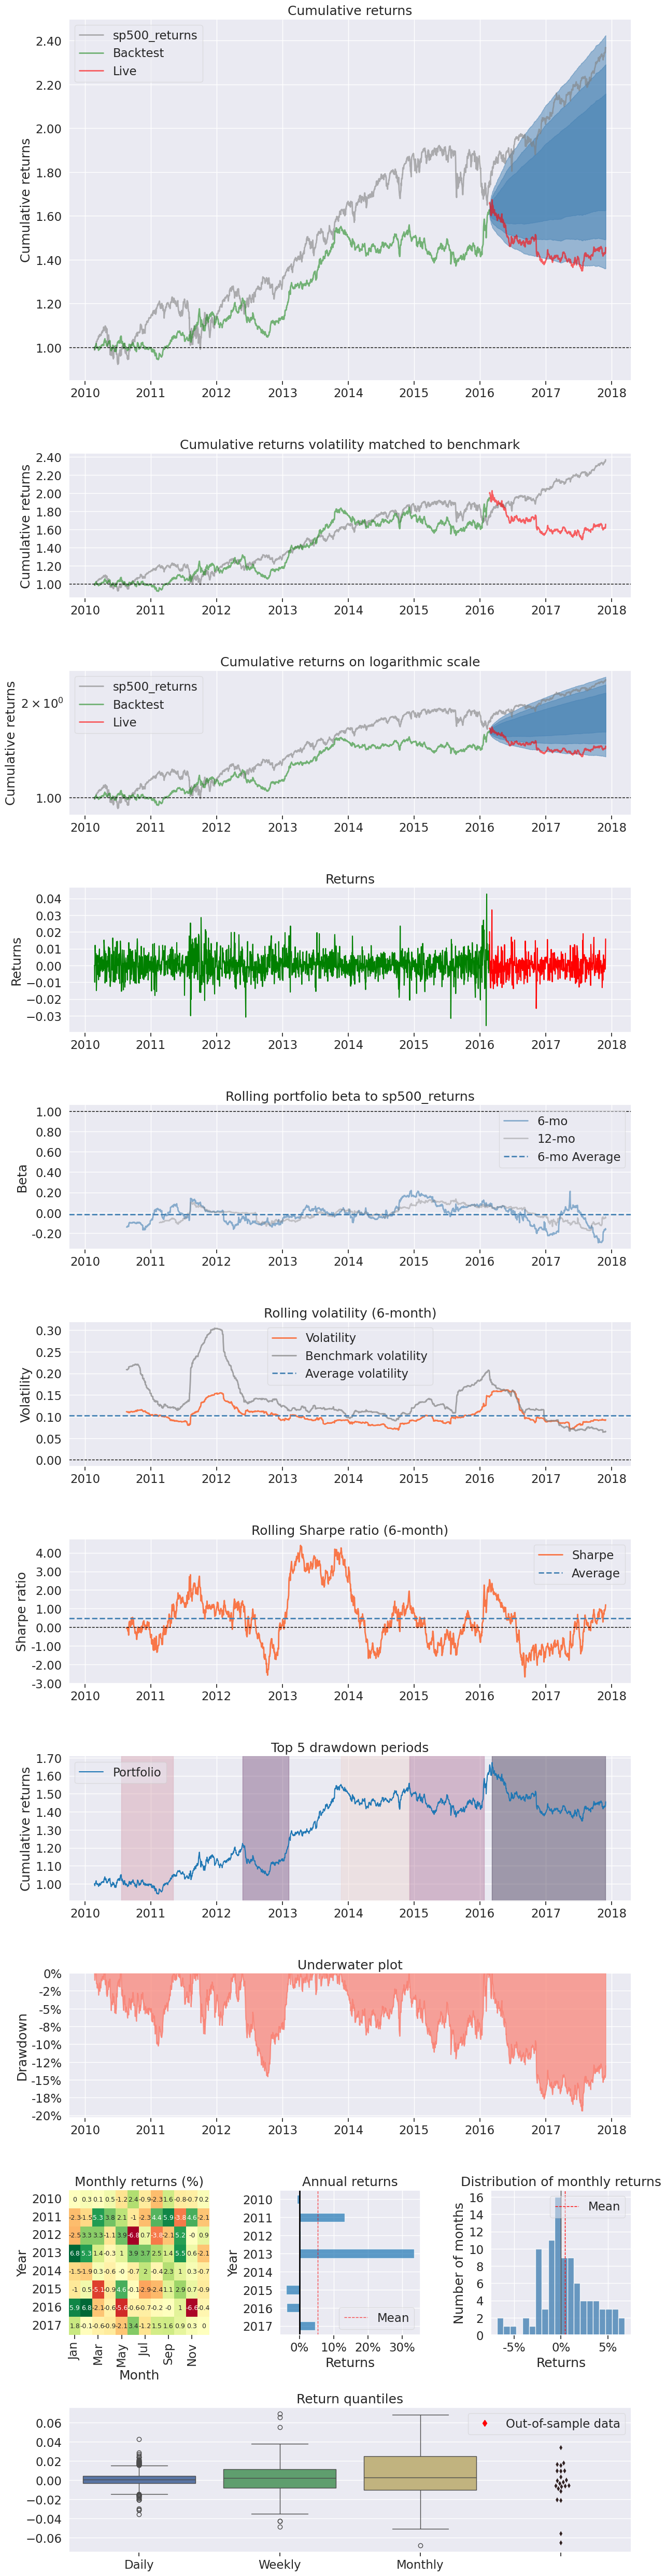

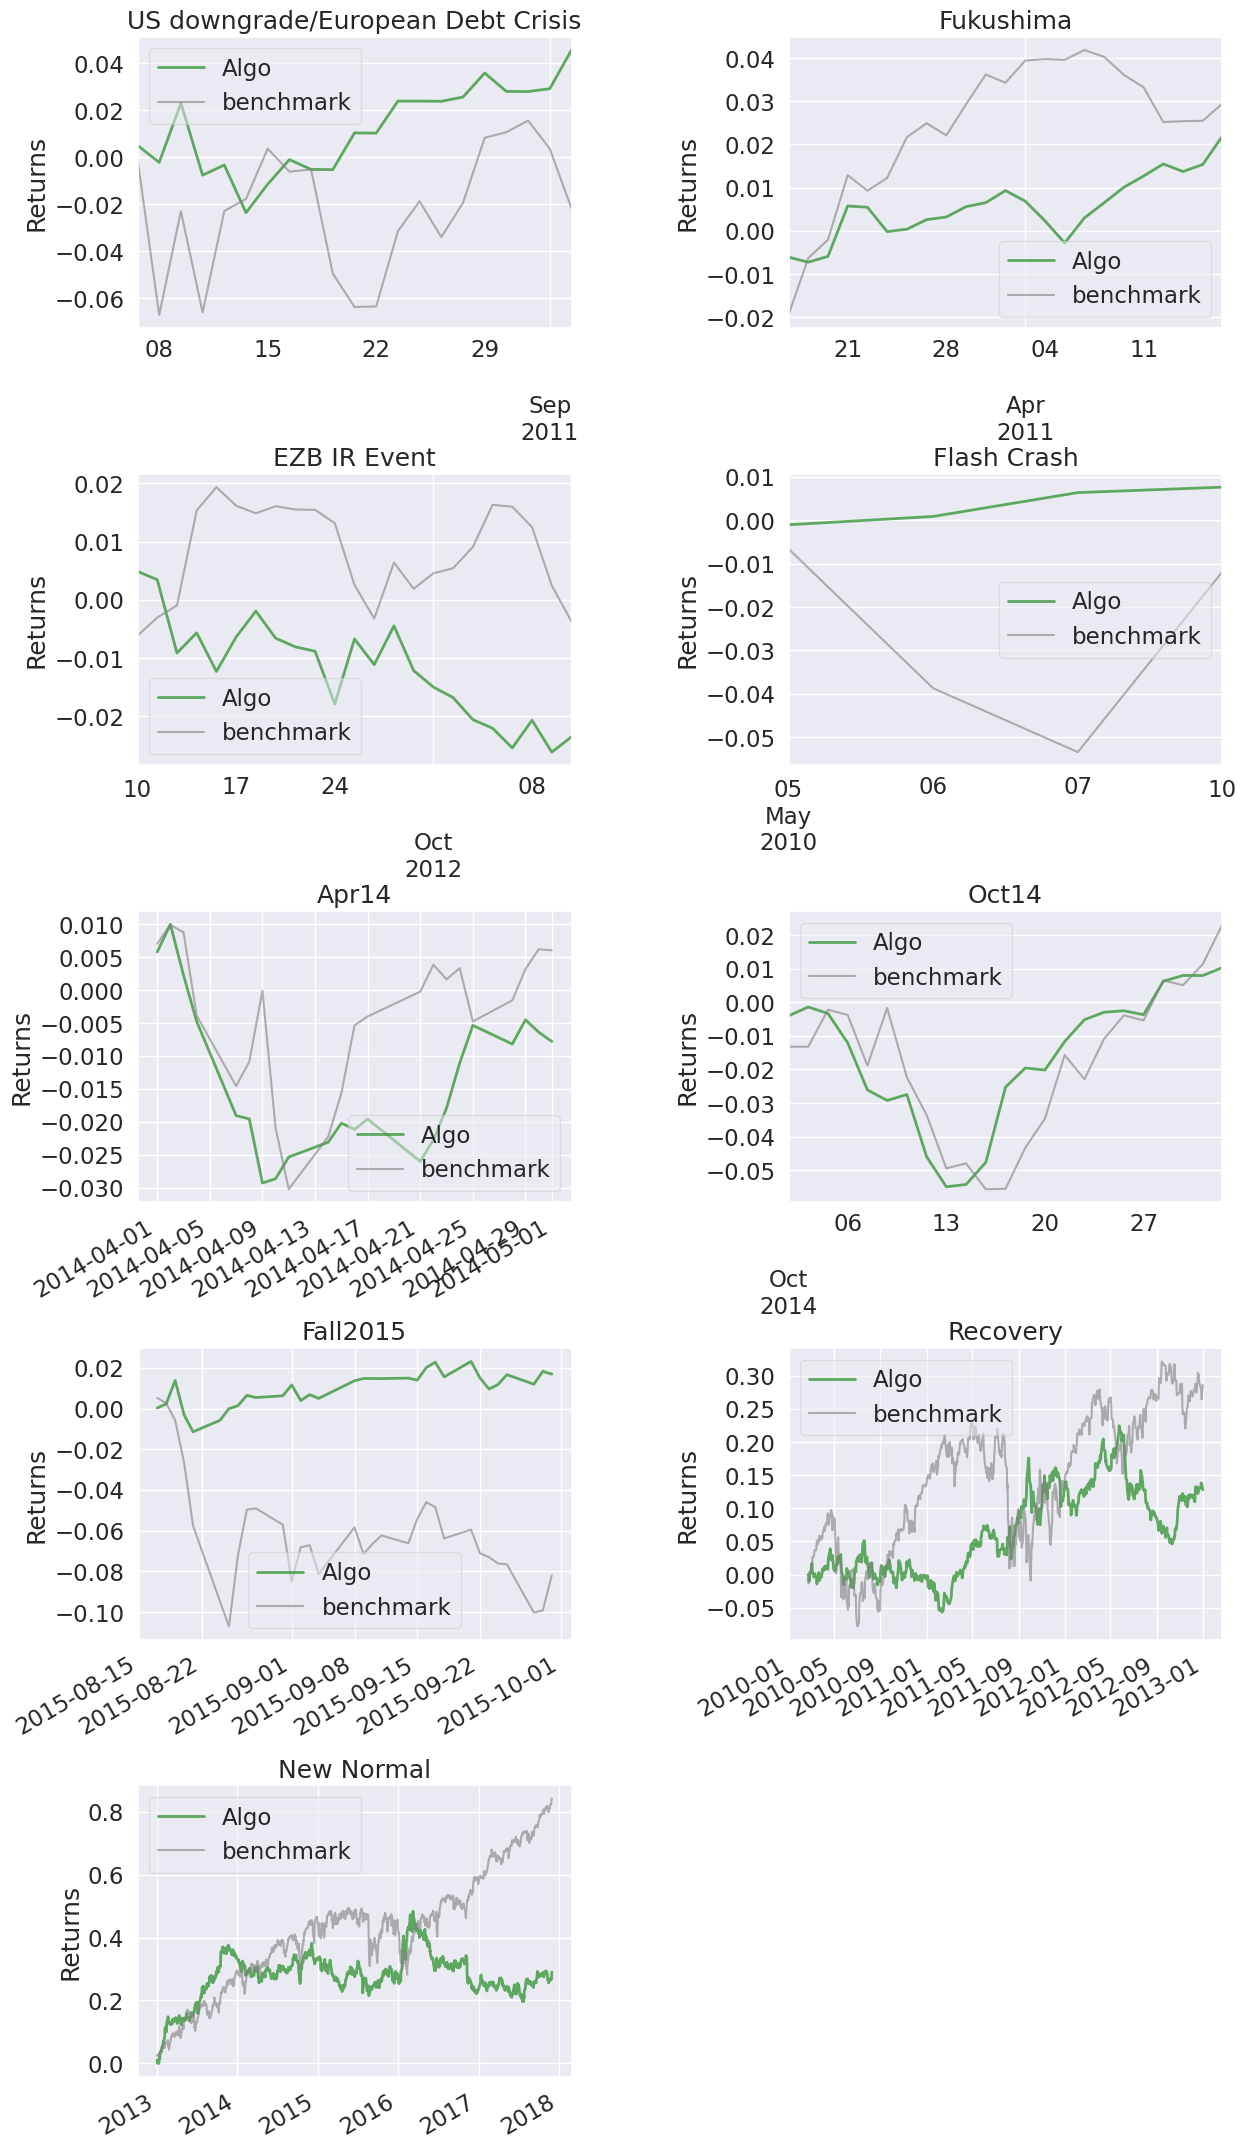

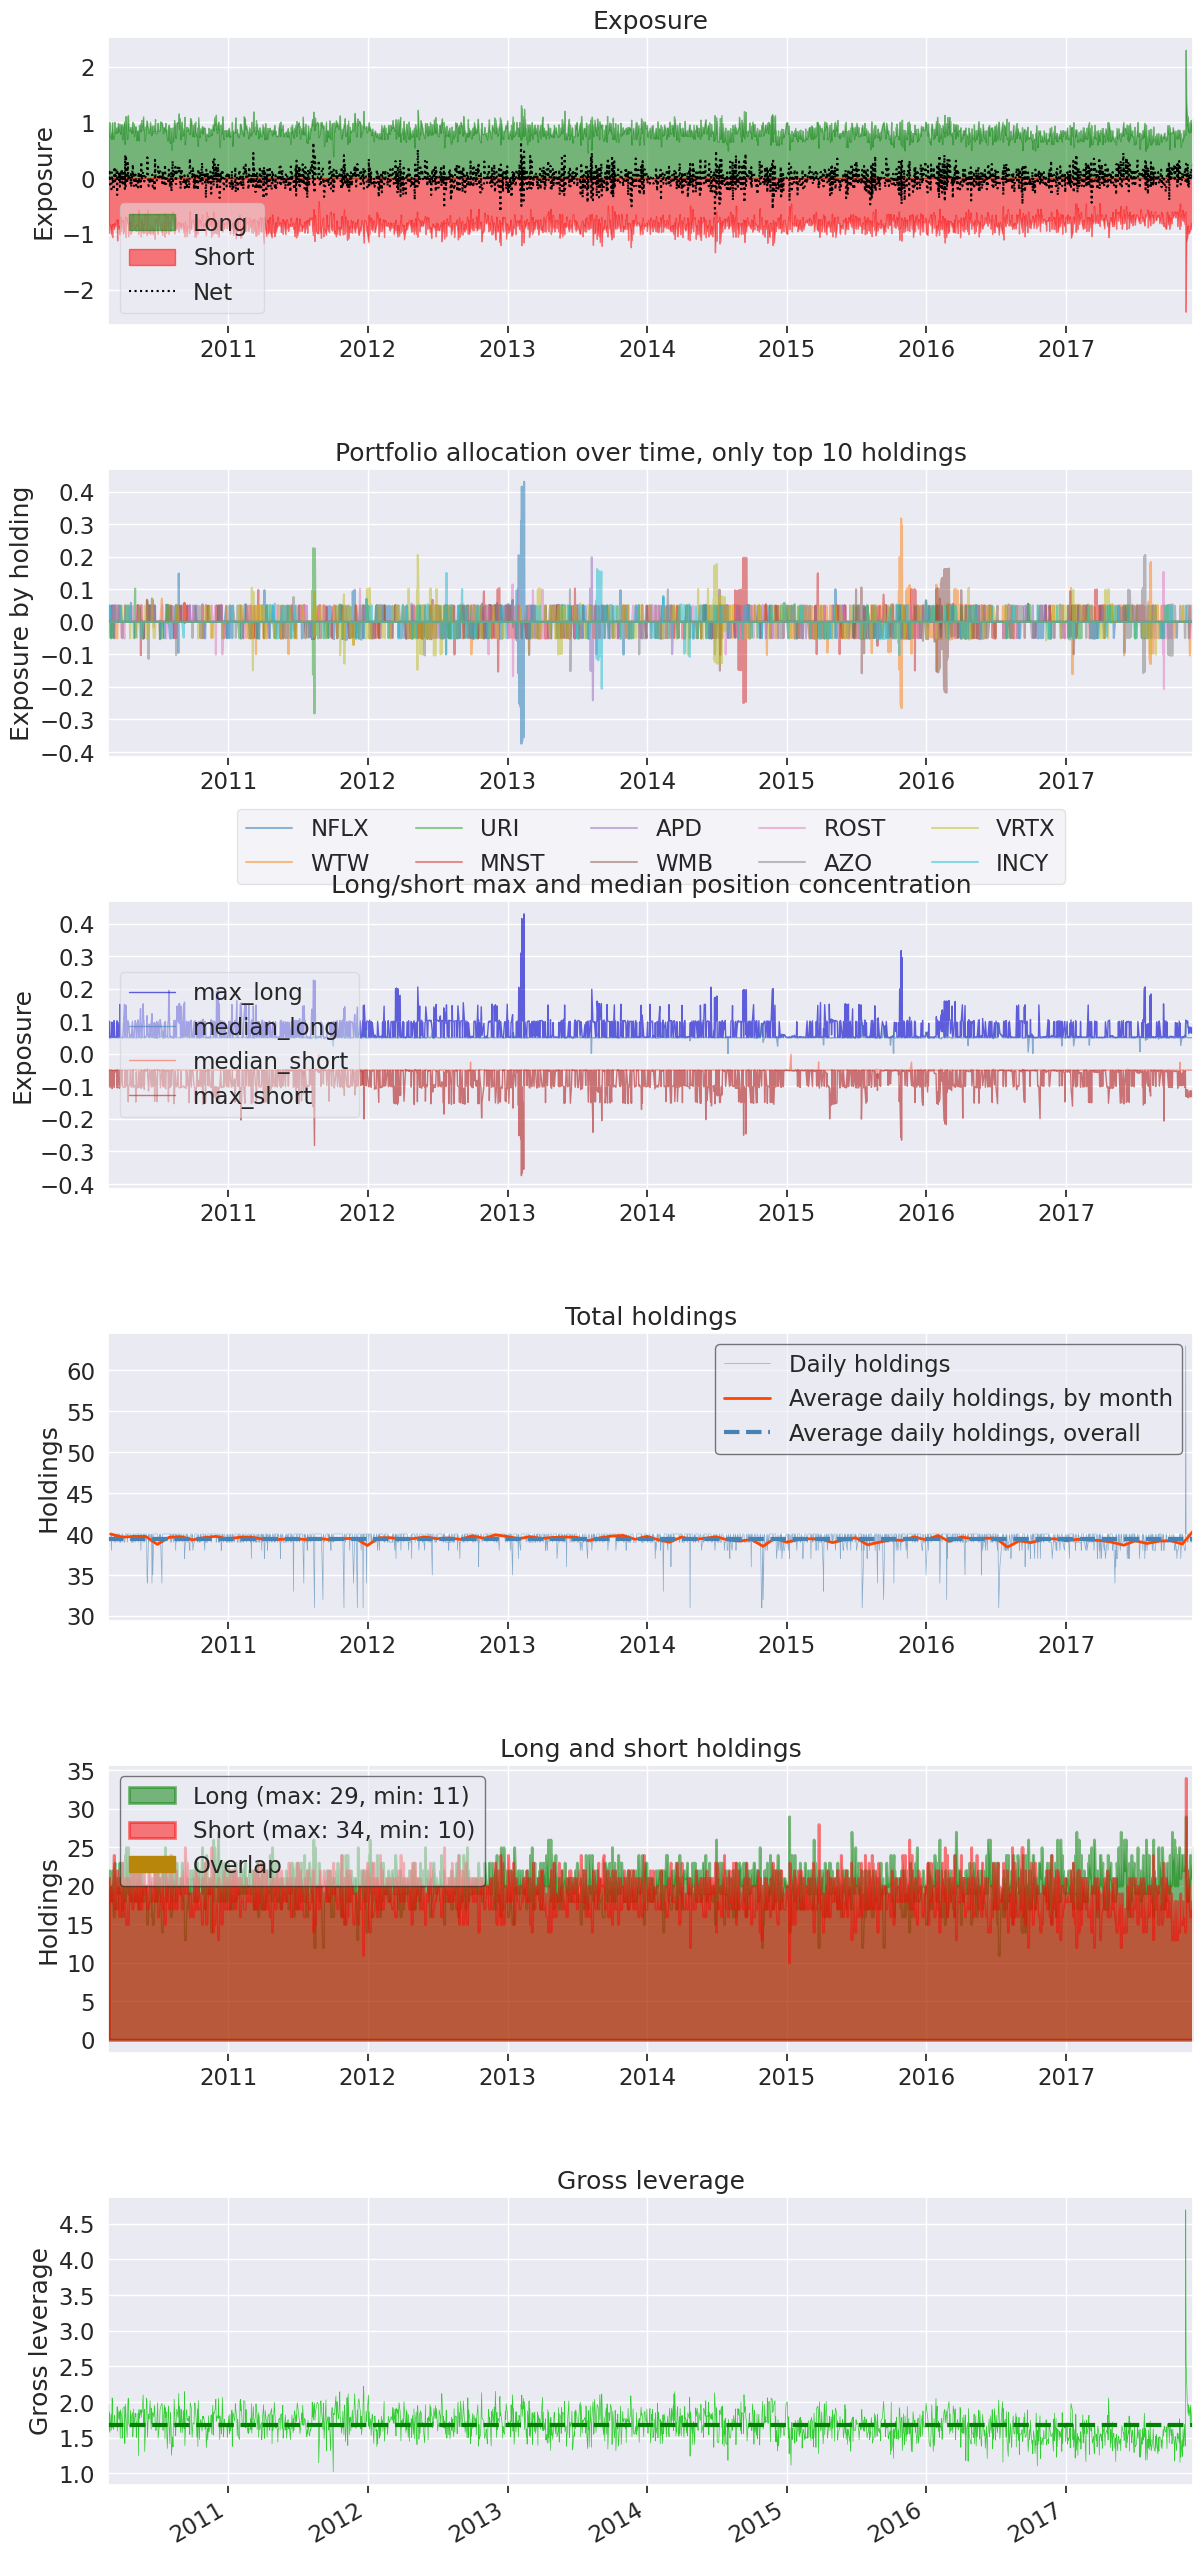

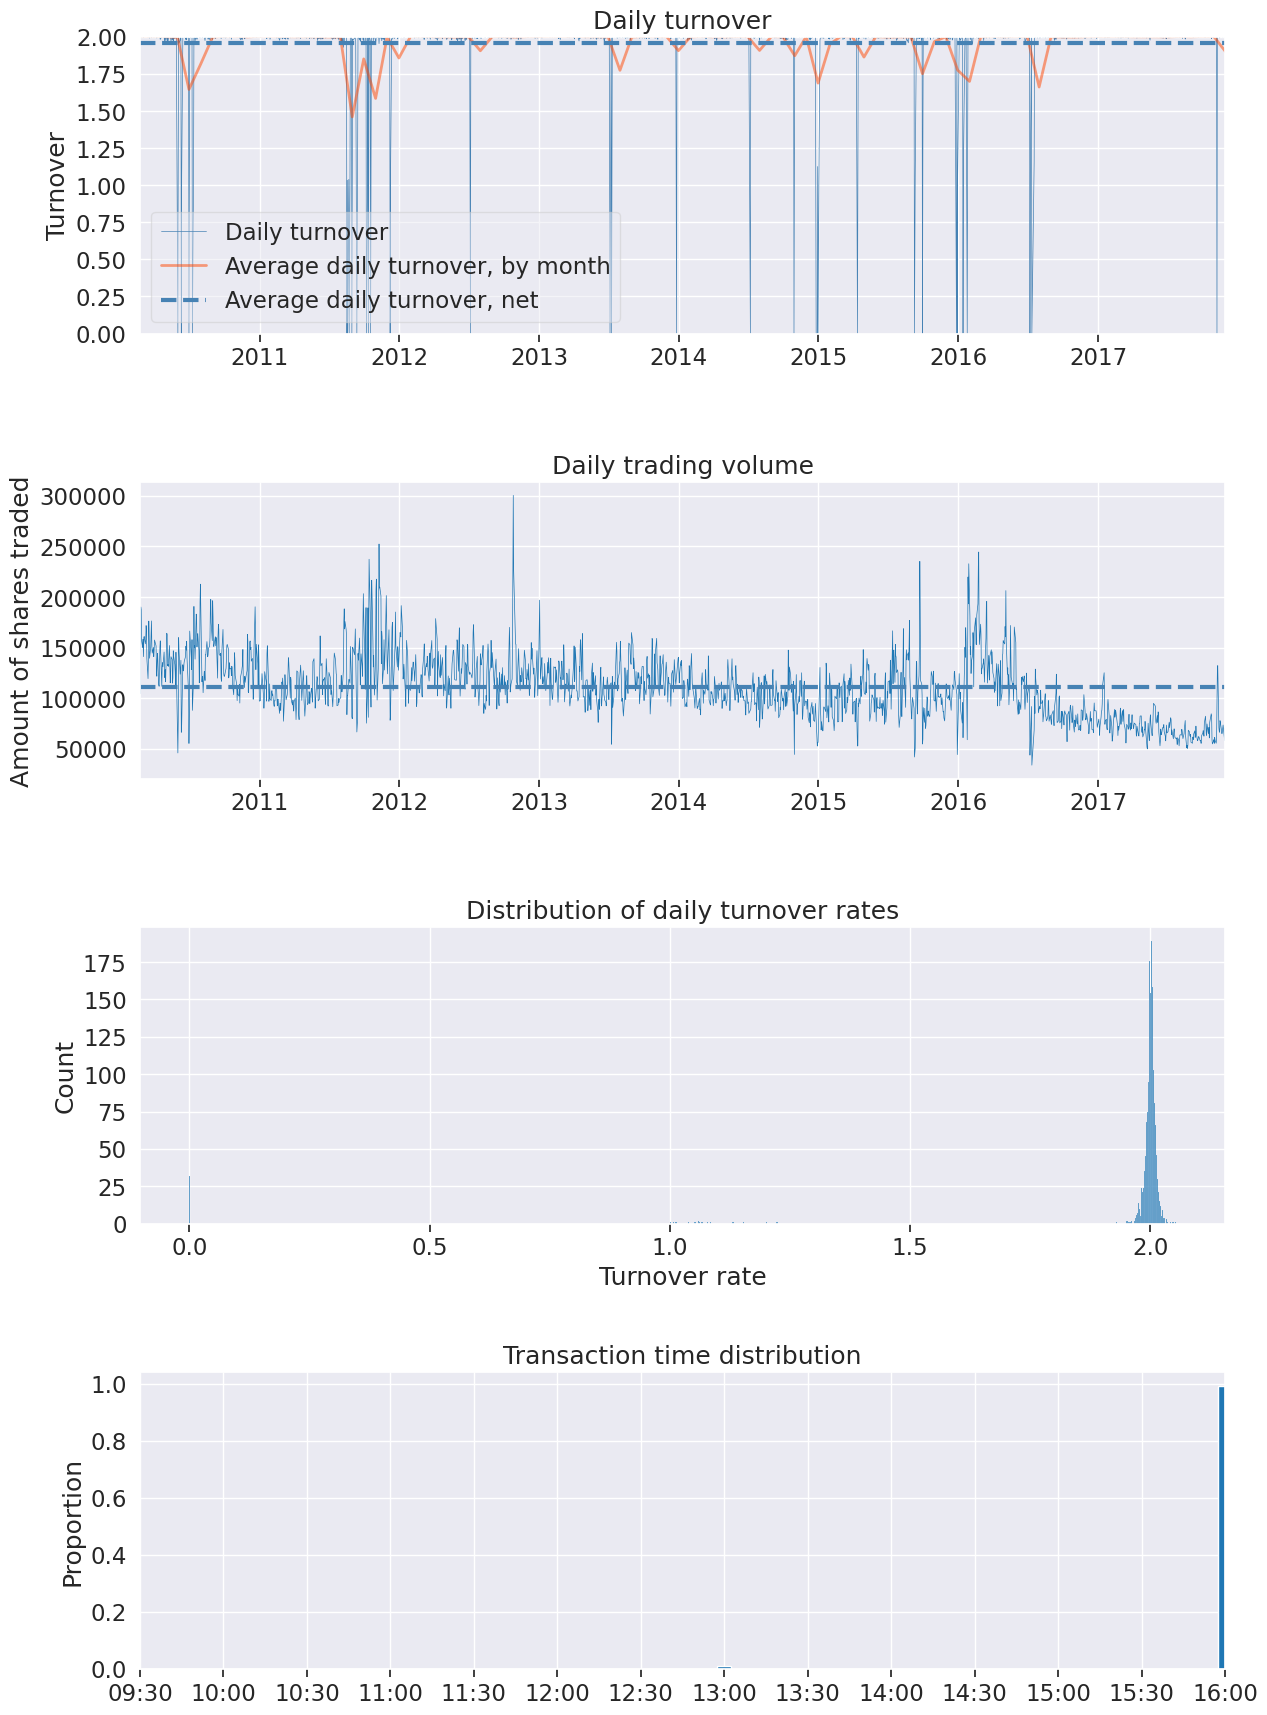

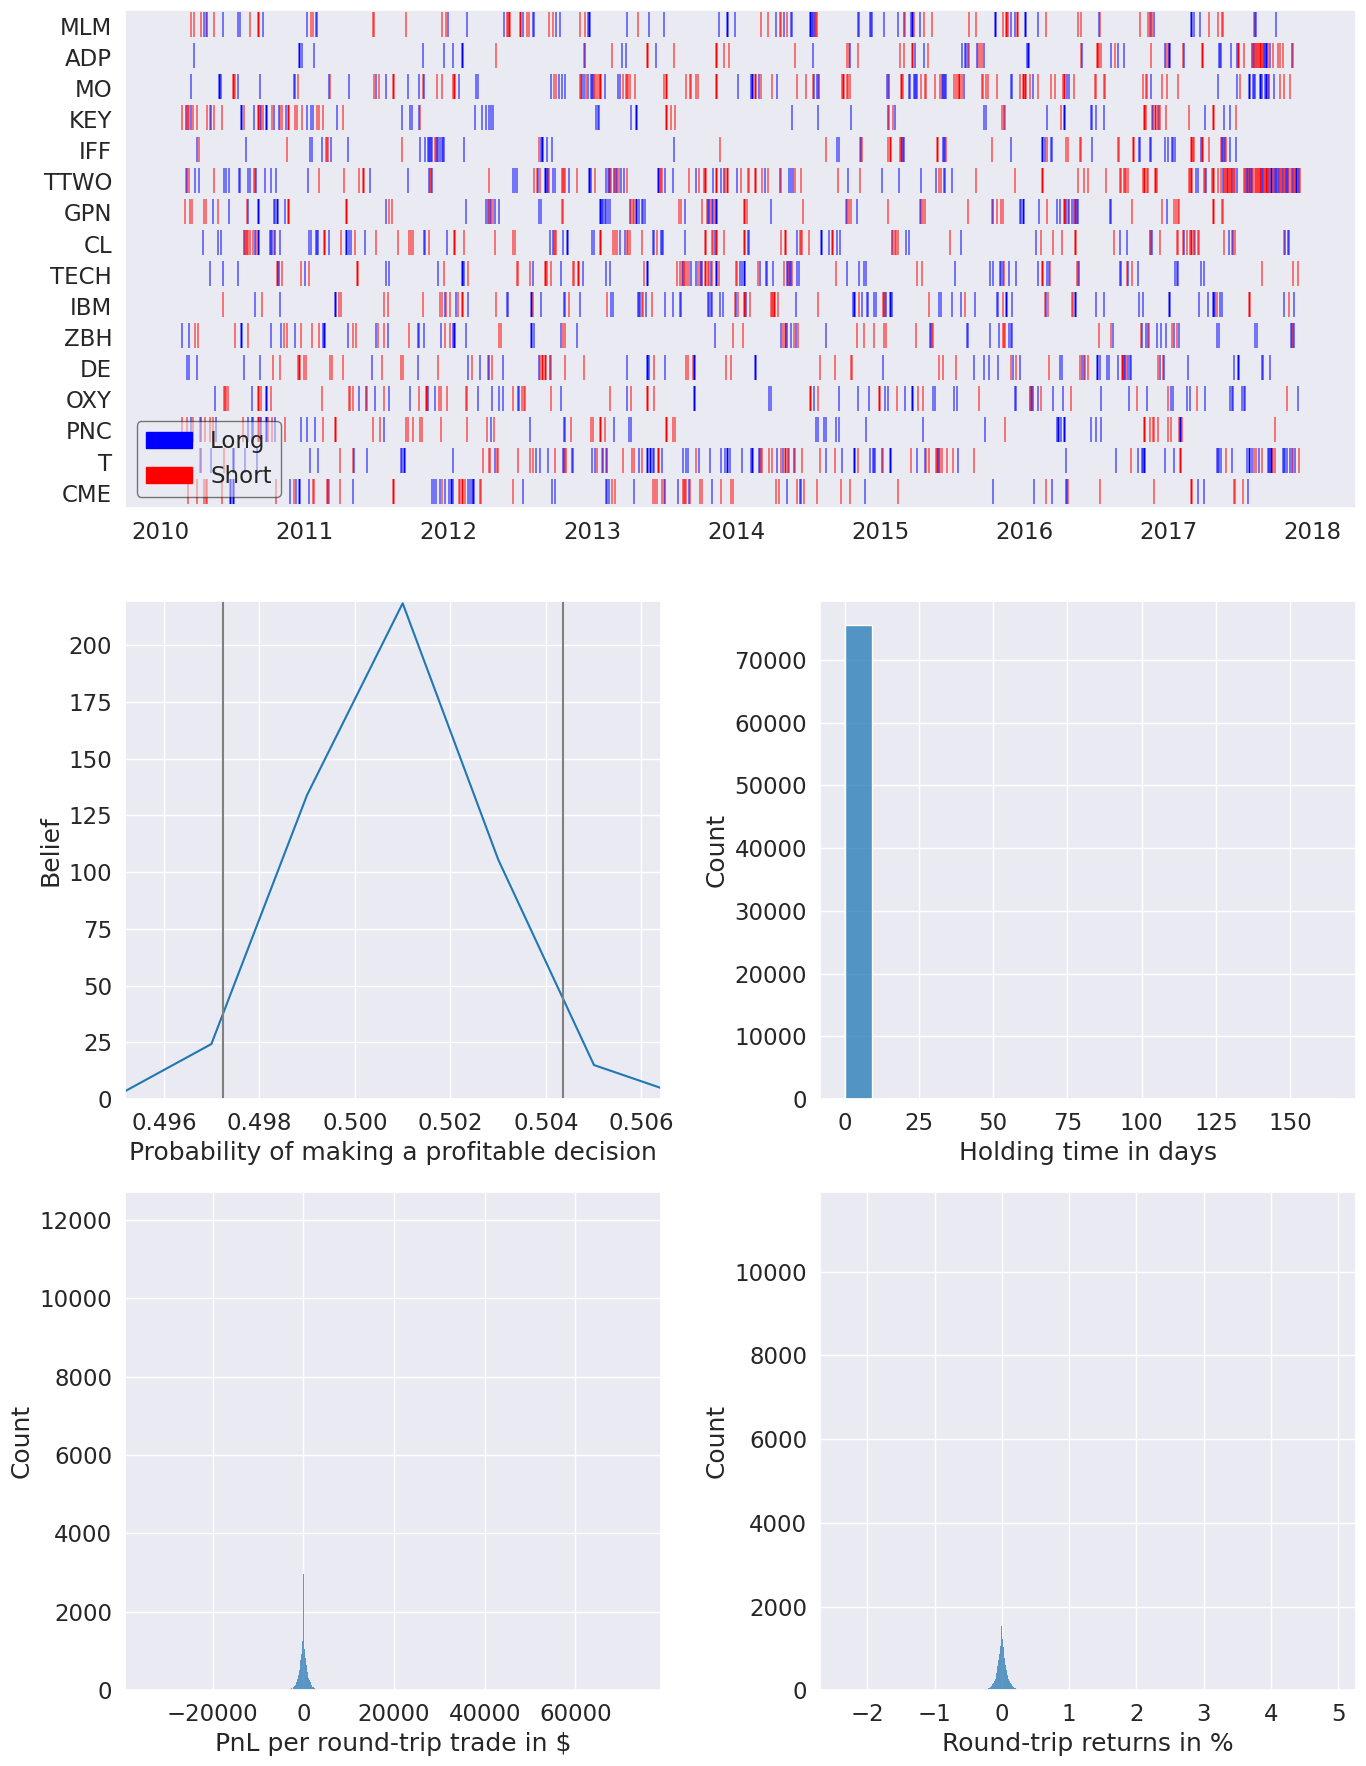

In [16]:
pf.create_full_tear_sheet(
    returns,
    positions=positions,
    transactions=transactions,
    benchmark_rets=benchmark_data,
    live_start_date=LIVE_DATE,
    round_trips=True
)

## Trading Strategy-II:

### As per the Signal Evaluation of the Model-4 Factors, we will long and short predictions in quantiles 5 and 4 respectively.

In [17]:
trading_strategy={
    "strategy":"quantile_based",
    "values":{
        "quantile_long":5,
        "quantile_short":4
}

}

In [18]:
backtester=BackTester(
    n_longs=20,
    n_shorts=20,
    min_positions=10,
    capital_base=1e6,
    commission_cost=0.00075,
    commission_min_trade_cost=0.01,
    slippage_spread=0.0,
    predictions_file=os.path.join(data_store,"factors.csv"),
    predictions_column_name="Model4_Factors",
    trading_strategy=trading_strategy
)

In [19]:
results=backtester.run_backtesting()

INFO: Model predictions loaded...
INFO: Missing Date Values added in Model Predictions...
INFO: Model Data Loader created...
INFO: Backtesting started for trading strategy-II...
INFO: Backtesting completed...


### Performance analysis using Pyfolio

#### Extracting information from Zipline Results

In [20]:
returns,positions,transactions=pf.utils.extract_rets_pos_txn_from_zipline(results)

#### Plotting Rolling Returns and Sharpe Ratio

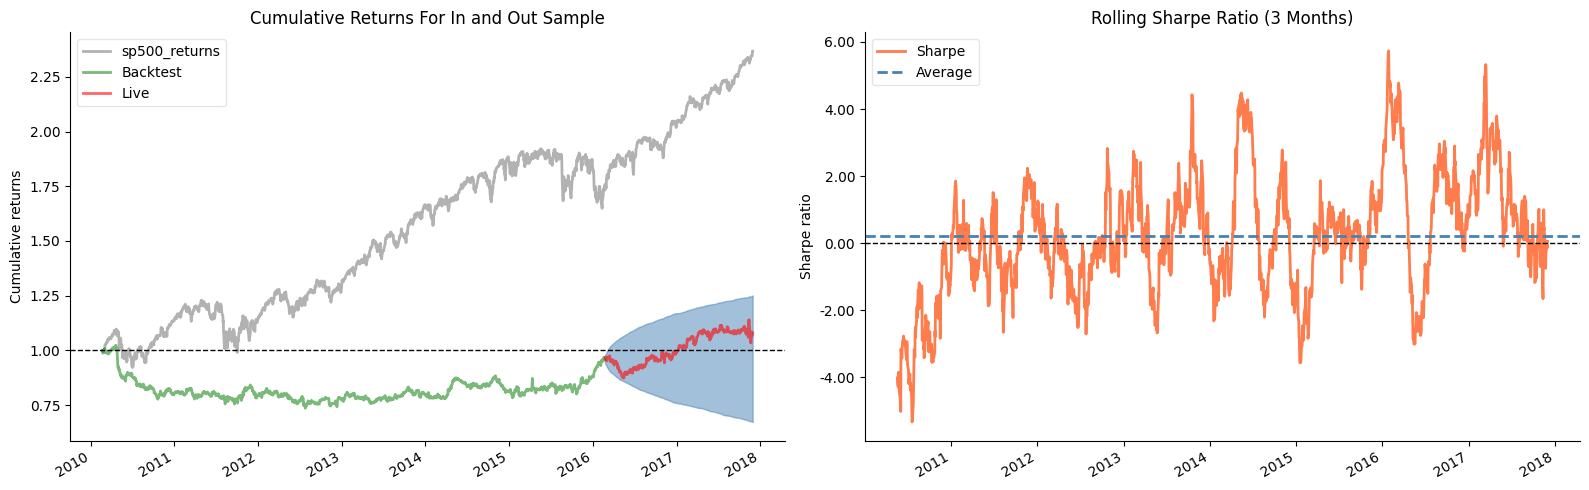

In [21]:
fig,axes=plt.subplots(ncols=2,figsize=(16,5))

plot_rolling_returns(
    returns,
    factor_returns=benchmark_data,
    live_start_date=LIVE_DATE,
    logy=False,
    cone_std=2,
    legend_loc="best",
    volatility_match=False,
    cone_function=forecast_cone_bootstrap,
    ax=axes[0]
)

plot_rolling_sharpe(returns,rolling_window=63,ax=axes[1])

axes[0].set_title("Cumulative Returns For In and Out Sample")
axes[1].set_title("Rolling Sharpe Ratio (3 Months)")

sns.despine()
fig.tight_layout()

#### Full Tear Sheet

Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,28.07,2010-04-22,2012-07-26,2017-02-01,1770
1,9.25,2017-11-13,2017-11-21,NaT,NaN
2,4.90,2017-07-17,2017-11-10,2017-11-13,86
3,4.30,2017-04-28,2017-05-26,2017-06-13,33
4,3.64,2017-03-08,2017-03-23,2017-04-03,19


Stress Events,mean,min,max
US downgrade/European Debt Crisis,0.03%,-3.03%,1.68%
Fukushima,-0.16%,-1.62%,1.20%
EZB IR Event,0.11%,-0.40%,1.35%
Flash Crash,-0.46%,-1.21%,0.26%
Apr14,0.43%,-0.67%,2.40%
Oct14,0.19%,-0.51%,1.16%
Fall2015,-0.03%,-2.17%,1.48%
Recovery,-0.03%,-3.03%,2.98%
New Normal,0.03%,-4.35%,7.59%


Top 10 long positions of all time,max
sid,
BEN,120.54%
AES,100.87%
CAH,68.30%
AON,46.01%
BAX,39.88%
BRO,39.73%
AFL,39.27%
AOS,39.17%
C,36.24%


Top 10 short positions of all time,max
sid,
BEN,-126.43%
AES,-105.36%
CAH,-63.42%
ADM,-46.80%
C,-41.23%
ADP,-40.59%
AON,-40.54%
AXP,-35.49%
AFL,-35.35%


Top 10 positions of all time,max
sid,
BEN,126.43%
AES,105.36%
CAH,68.30%
ADM,46.80%
AON,46.01%
C,41.23%
ADP,40.59%
BAX,39.88%
BRO,39.73%


...

PnL stats,All trades,Short trades,Long trades
Total profit,$323981.68,$-1189598.86,$1513580.54
Gross profit,$21556099.00,$10095056.69,$11461042.30
Gross loss,$-21232117.31,$-11284655.55,$-9947461.76
Profit factor,$1.02,$0.89,$1.15
Avg. trade net profit,$4.19,$-29.63,$40.67
Avg. winning trade,$563.01,$533.37,$592.00
Avg. losing trade,$-552.91,$-541.36,$-566.61
Ratio Avg. Win:Avg. Loss,$1.02,$0.99,$1.04
Largest winning trade,$61661.49,$20589.24,$61661.49
Largest losing trade,$-47689.24,$-36204.46,$-47689.24


Duration stats,All trades,Short trades,Long trades
Avg duration,1 days 12:49:00.297606121,1 days 11:52:59.862345556,1 days 13:49:24.728371843
Median duration,1 days 00:00:00,1 days 00:00:00,1 days 00:00:00
Longest duration,56 days 00:00:00,39 days 00:00:00,56 days 00:00:00
Shortest duration,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00


Return stats,All trades,Short trades,Long trades
Avg returns all round_trips,0.00%,-0.00%,0.00%
Avg returns winning,0.07%,0.06%,0.07%
Avg returns losing,-0.06%,-0.06%,-0.07%
Median returns all round_trips,0.00%,-0.00%,0.00%
Median returns winning,0.04%,0.04%,0.04%
Median returns losing,-0.04%,-0.04%,-0.04%
Largest winning trade,6.87%,2.60%,6.87%
Largest losing trade,-4.96%,-4.15%,-4.96%


Symbol stats,A,ACGL,ACN,ADI,ADM,ADP,ADSK,AEE,AEP,AES,AFL,AIG,AIZ,AJG,ALB,ALGN,ALL,AMAT,AMD,AME,AMGN,AMP,AMT,AON,AOS,APA,APD,APH,ARE,ATO,AVB,AVGO,AVY,AWK,AXP,AZO,BA,BAC,BAX,BBY,BDX,BEN,BG,BIIB,BK,BLDR,BLK,BMY,BR,BRO,BSX,BXP,C,CAG,CAH,CAT,CB,CCI,CCL,CDNS,CF,CHD,CHRW,CI,CINF,CL,CLX,CME,CMG,CMI,CMS,CNC,CNP,COF,COO,COP,CPB,CPRT,CPT,CRL,CRM,CSCO,CSGP,CSX,CTAS,CTSH,CVS,CVX,D,DAL,DE,DECK,DG,DGX,DHI,DHR,DIS,DLR,DLTR,DOV,DPZ,DRI,DTE,DUK,DVA,DVN,DXCM,EA,EBAY,ECL,ED,EFX,EIX,EL,EMN,EMR,EOG,EQIX,EQR,EQT,ERIE,ES,ESS,ETN,ETR,EW,EXC,EXPD,EXPE,EXR,F,FCX,FDS,FDX,FE,FFIV,FICO,FIS,FITB,FOX,FOXA,FRT,FTNT,GD,GE,GILD,GIS,GLW,GOOGL,GPC,GPN,GS,GWW,HAL
Avg returns all round_trips,-0.00%,0.00%,-0.00%,0.00%,-0.00%,-0.00%,0.01%,-0.00%,-0.00%,0.00%,-0.00%,0.01%,0.00%,-0.01%,0.00%,0.00%,-0.01%,-0.01%,-0.01%,-0.00%,-0.00%,0.00%,-0.01%,0.01%,0.01%,-0.00%,0.00%,-0.01%,0.00%,0.00%,0.00%,0.01%,0.00%,-0.00%,-0.00%,0.00%,-0.01%,0.00%,0.01%,0.00%,0.00%,-0.01%,-0.00%,0.01%,-0.00%,0.01%,0.01%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,-0.00%,0.00%,0.00%,-0.00%,-0.00%,0.00%,-0.00%,-0.00%,0.00%,-0.01%,0.00%,0.00%,0.00%,0.00%,0.00%,0.01%,0.00%,0.00%,0.01%,0.00%,-0.00%,0.00%,0.00%,-0.00%,-0.00%,0.00%,-0.00%,-0.00%,0.00%,-0.01%,0.00%,0.00%,-0.00%,-0.00%,-0.01%,0.01%,-0.00%,0.00%,-0.01%,-0.00%,0.00%,0.00%,-0.00%,0.00%,0.00%,0.01%,0.01%,0.00%,-0.01%,-0.00%,-0.00%,-0.00%,-0.00%,-0.01%,-0.00%,0.01%,-0.00%,0.00%,0.00%,-0.00%,-0.01%,-0.00%,0.00%,0.01%,0.00%,-0.01%,-0.01%,0.00%,-0.00%,-0.00%,-0.02%,0.00%,0.00%,-0.01%,-0.02%,0.01%,-0.01%,-0.01%,-0.00%,0.01%,-0.00%,-0.01%,-0.00%,-0.07%,-0.02%,0.01%,-0.02%,0.01%,0.01%,0.00%,-0.01%,-0.02%,0.05%,0.02%,0.01%,0.00%,0.06%,0.02%,0.01%,0.10%,0.03%
Avg returns winning,0.07%,0.05%,0.06%,0.08%,0.06%,0.05%,0.10%,0.06%,0.04%,0.09%,0.05%,0.07%,0.06%,0.04%,0.07%,0.09%,0.04%,0.07%,0.14%,0.06%,0.06%,0.07%,0.06%,0.06%,0.08%,0.08%,0.05%,0.06%,0.05%,0.05%,0.06%,0.11%,0.07%,0.05%,0.06%,0.05%,0.06%,0.09%,0.06%,0.09%,0.05%,0.07%,0.06%,0.09%,0.06%,0.17%,0.08%,0.05%,0.06%,0.06%,0.07%,0.06%,0.09%,0.05%,0.07%,0.07%,0.04%,0.05%,0.07%,0.06%,0.09%,0.06%,0.05%,0.07%,0.05%,0.04%,0.04%,0.06%,0.09%,0.07%,0.05%,0.10%,0.05%,0.07%,0.06%,0.06%,0.04%,0.04%,0.06%,0.06%,0.09%,0.05%,0.07%,0.07%,0.06%,0.06%,0.05%,0.05%,0.04%,0.09%,0.06%,0.08%,0.06%,0.05%,0.08%,0.04%,0.05%,0.06%,0.07%,0.07%,0.07%,0.05%,0.05%,0.04%,0.04%,0.07%,0.10%,0.08%,0.07%,0.04%,0.04%,0.05%,0.04%,0.05%,0.06%,0.05%,0.09%,0.06%,0.04%,0.06%,0.05%,0.03%,0.05%,0.05%,0.04%,0.07%,0.03%,0.06%,0.08%,0.04%,0.06%,0.09%,0.04%,0.05%,0.03%,0.07%,0.03%,0.04%,0.06%,0.07%,0.08%,0.03%,0.06%,0.05%,0.08%,0.05%,0.06%,0.06%,0.00%,0.06%,0.04%,0.01%,0.10%,0.03%
Avg returns losing,-0.08%,-0.05%,-0.06%,-0.07%,-0.06%,-0.04%,-0.10%,-0.05%,-0.04%,-0.09%,-0.05%,-0.07%,-0.06%,-0.05%,-0.07%,-0.10%,-0.05%,-0.08%,-0.14%,-0.06%,-0.06%,-0.07%,-0.06%,-0.04%,-0.07%,-0.09%,-0.06%,-0.07%,-0.05%,-0.05%,-0.06%,-0.09%,-0.06%,-0.05%,-0.06%,-0.05%,-0.07%,-0.07%,-0.05%,-0.10%,-0.04%,-0.09%,-0.06%,-0.08%,-0.07%,-0.15%,-0.06%,-0.05%,-0.06%,-0.05%,-0.07%,-0.05%,-0.08%,-0.05%,-0.07%,-0.06%,-0.05%,-0.05%,-0.06%,-0.07%,-0.10%,-0.06%,-0.06%,-0.06%,-0.05%,-0.04%,-0.04%,-0.06%,-0.09%,-0.07%,-0.05%,-0.08%,-0.06%,-0.07%,-0.05%,-0.07%,-0.04%,-0.04%,-0.05%,-0.06%,-0.09%,-0.05%,-0.08%,-0.08%,-0.05%,-0.06%,-0.05%,-0.06%,-0.04%,-0.09%,-0.05%,-0.10%,-0.06%,-0.04%,-0.07%,-0.05%,-0.05%,-0.05%,-0.06%,-0.05%,-0.07%,-0.07%,-0.04%,-0.04%,-0.04%,-0.08%,-0.09%,-0.07%,-0.07%,-0.05%,-0.04%,-0.04%,-0.04%,-0.05%,-0.06%,-0.04%,-0.08%,-0.06%,-0.04%,-0.06%,-0.04%,-0.04%,-0.05%,-0.07%,-0.04%,-0.06%,-0.04%,-0.06%,-0.07%,-0.07%,-0.07%,-0.10%,-0.03%,-0.07%,-0.03%,-0.06%,-0.08%,-0.07%,-0.05%,-0.08%,-0.07%,-0.03%,-0.14%,-0.07%,-0.06%,NaN,-0.01%,-0.07%,NaN,NaN,-0.01%,NaN,NaN,NaN
Median returns all round_trips,0.00%,0.00%,-0.00%,0.00%,-0.00%,-0.00%,0.00%,-0.00%,0.00%,0.00%,-0.00%,0.00%,0.00%,-0.00%,-0.00%,0.00%,-0.00%,-0.00%,-0.00%,0.00%,-0.00%,-0.00%,-0.00%,0.00%,0.00%,0.00%,0.00%,-0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,-0.00%,-0.00%,-0.00%,0.00%,-0.00%,0.00%,0.00%,0.00%,-0.00%,-0.00%,0.00%,0.00%,

Profitability (PnL / PnL total) per name,
symbol,
ADSK,20.97%
BLDR,20.40%
AVGO,19.73%
AOS,19.02%
BIIB,18.25%
AES,15.77%
BLK,15.57%
CNC,13.57%
BAX,13.29%


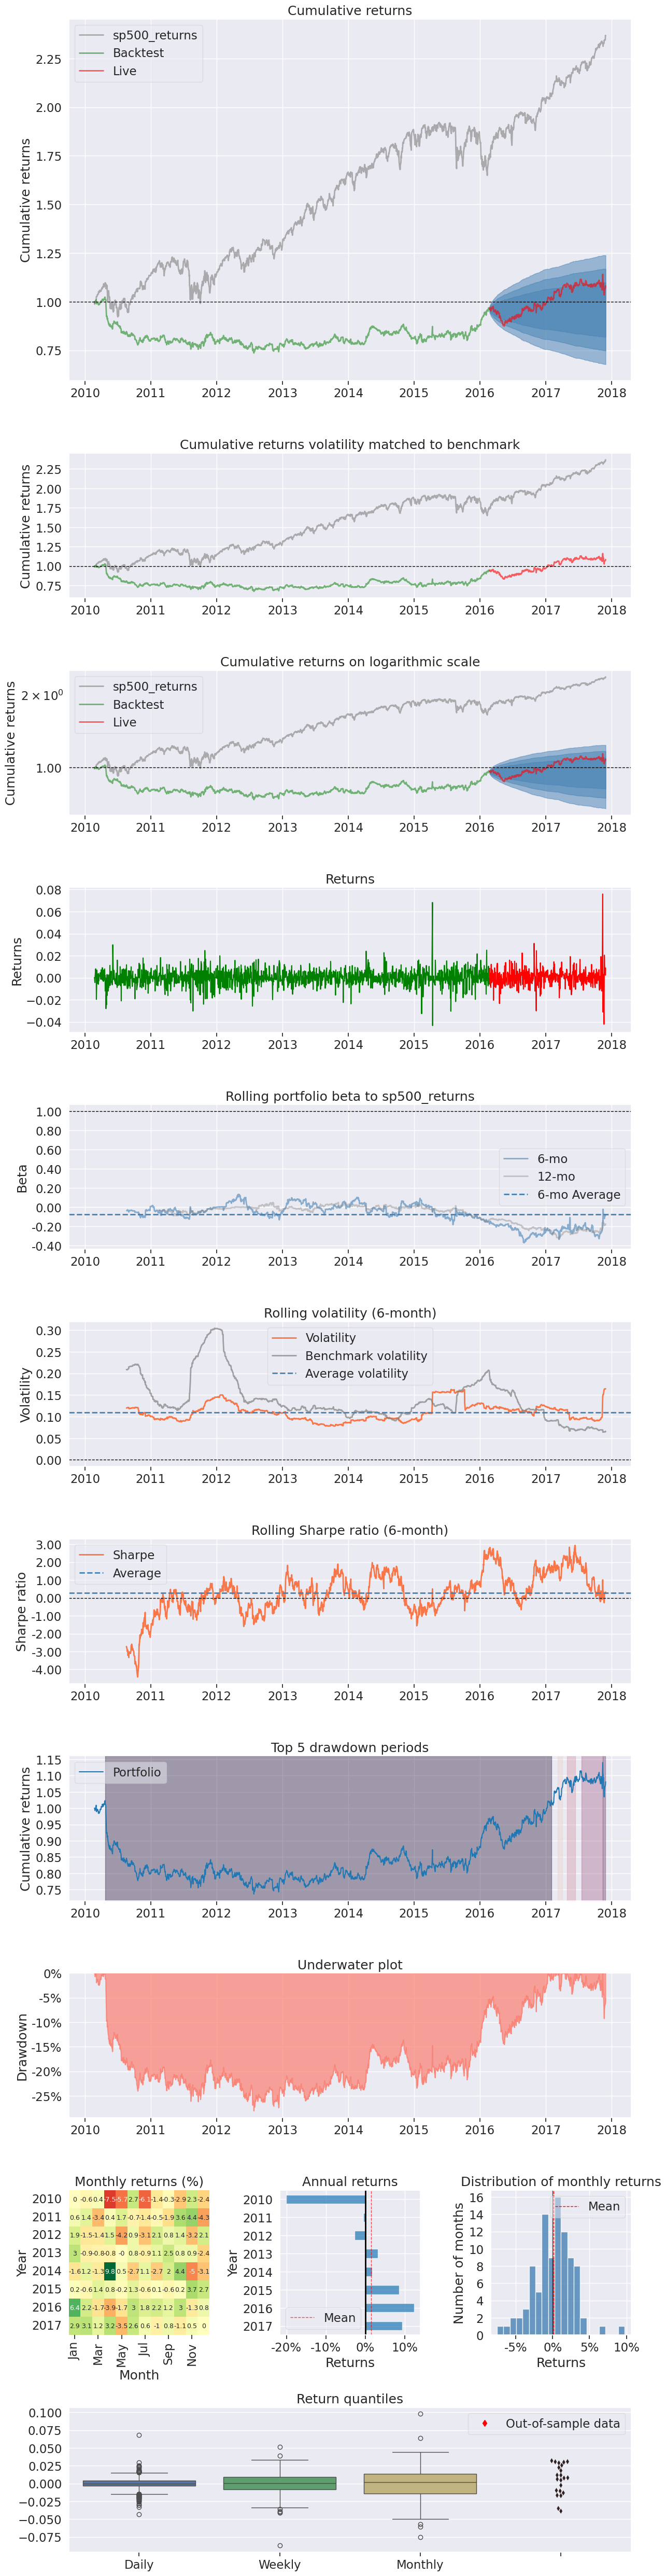

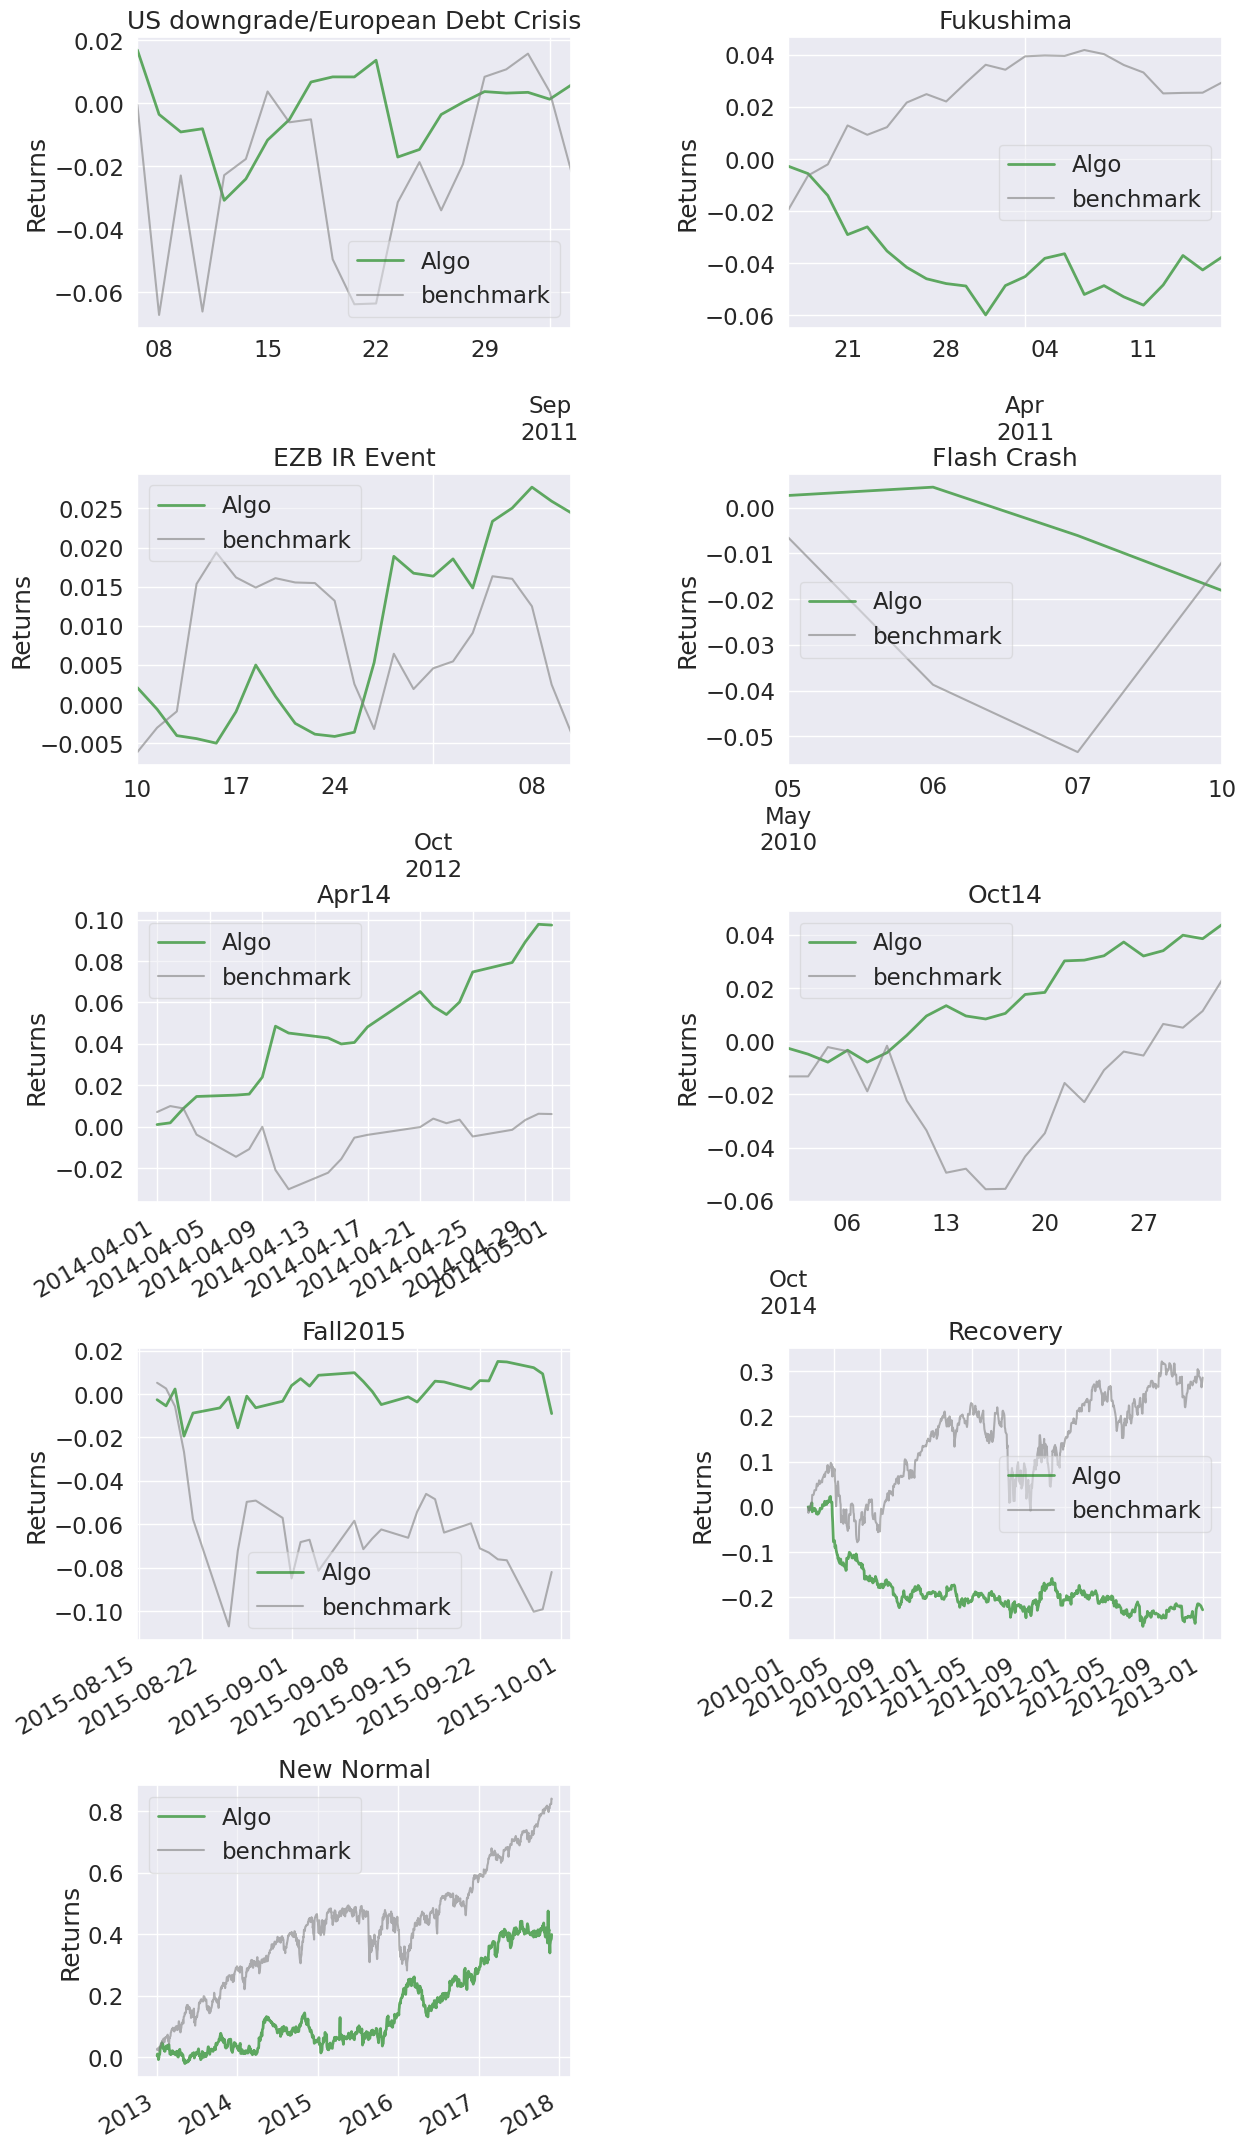

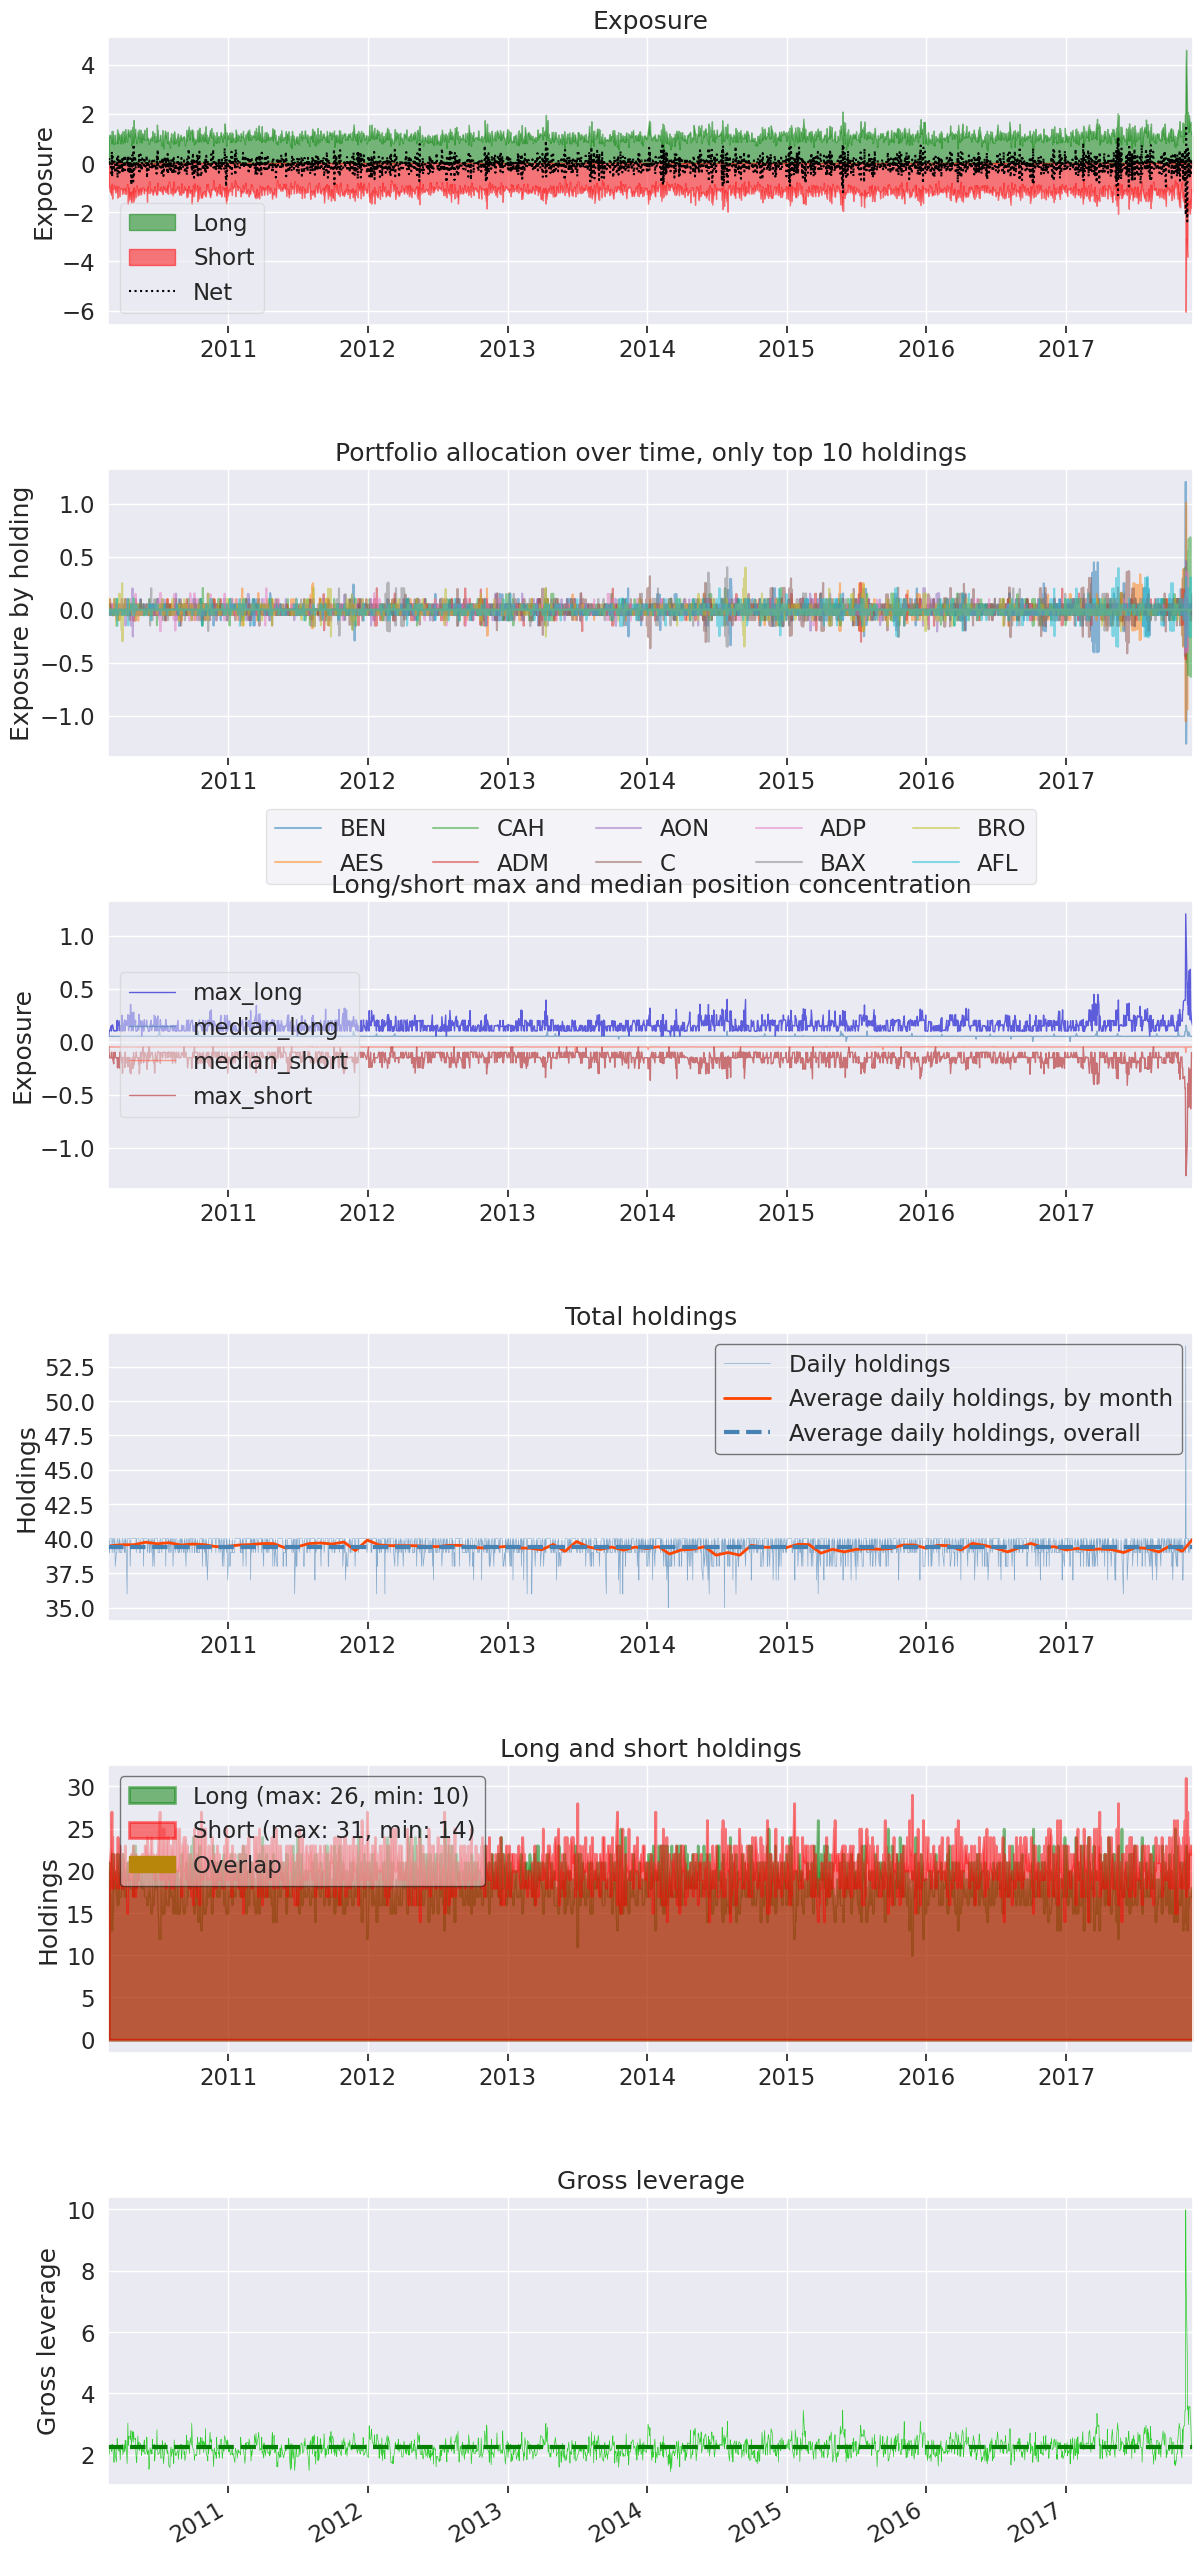

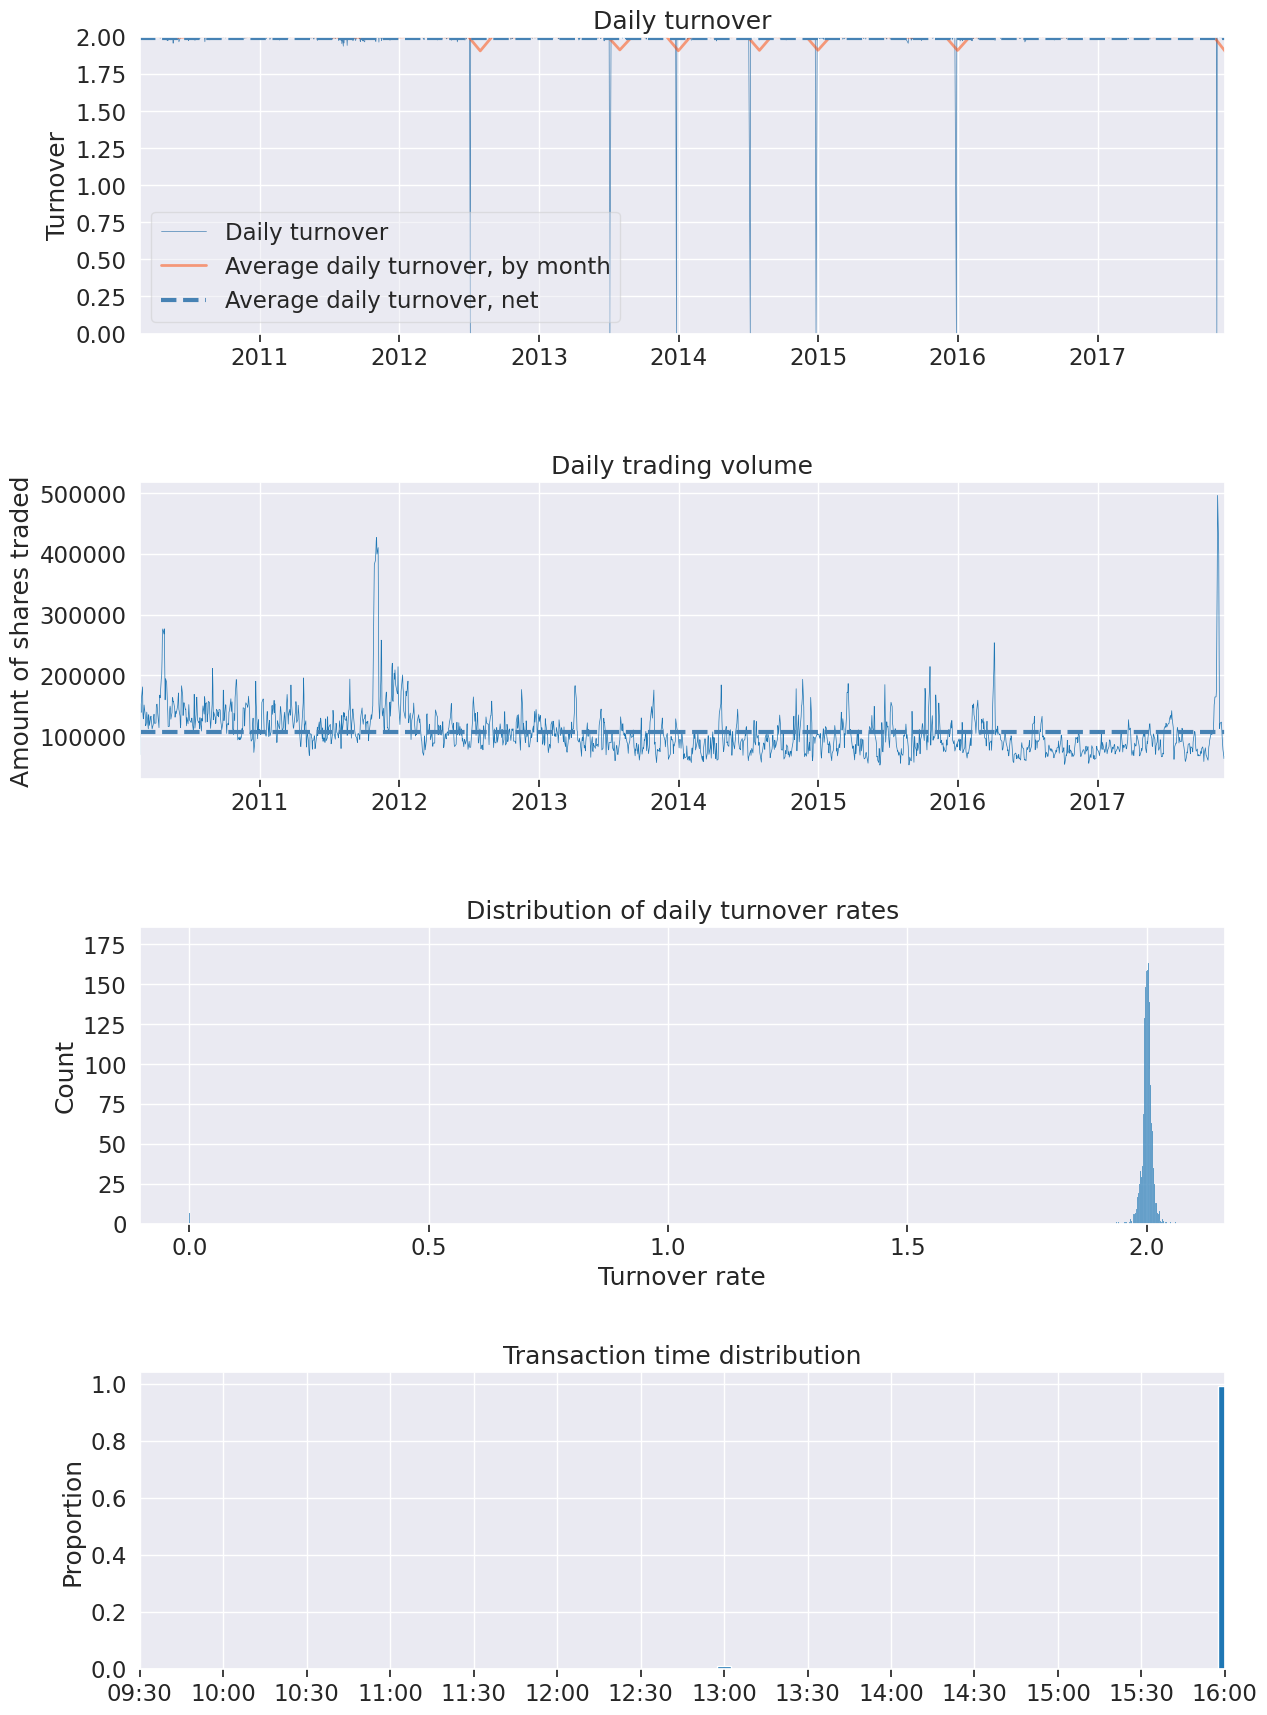

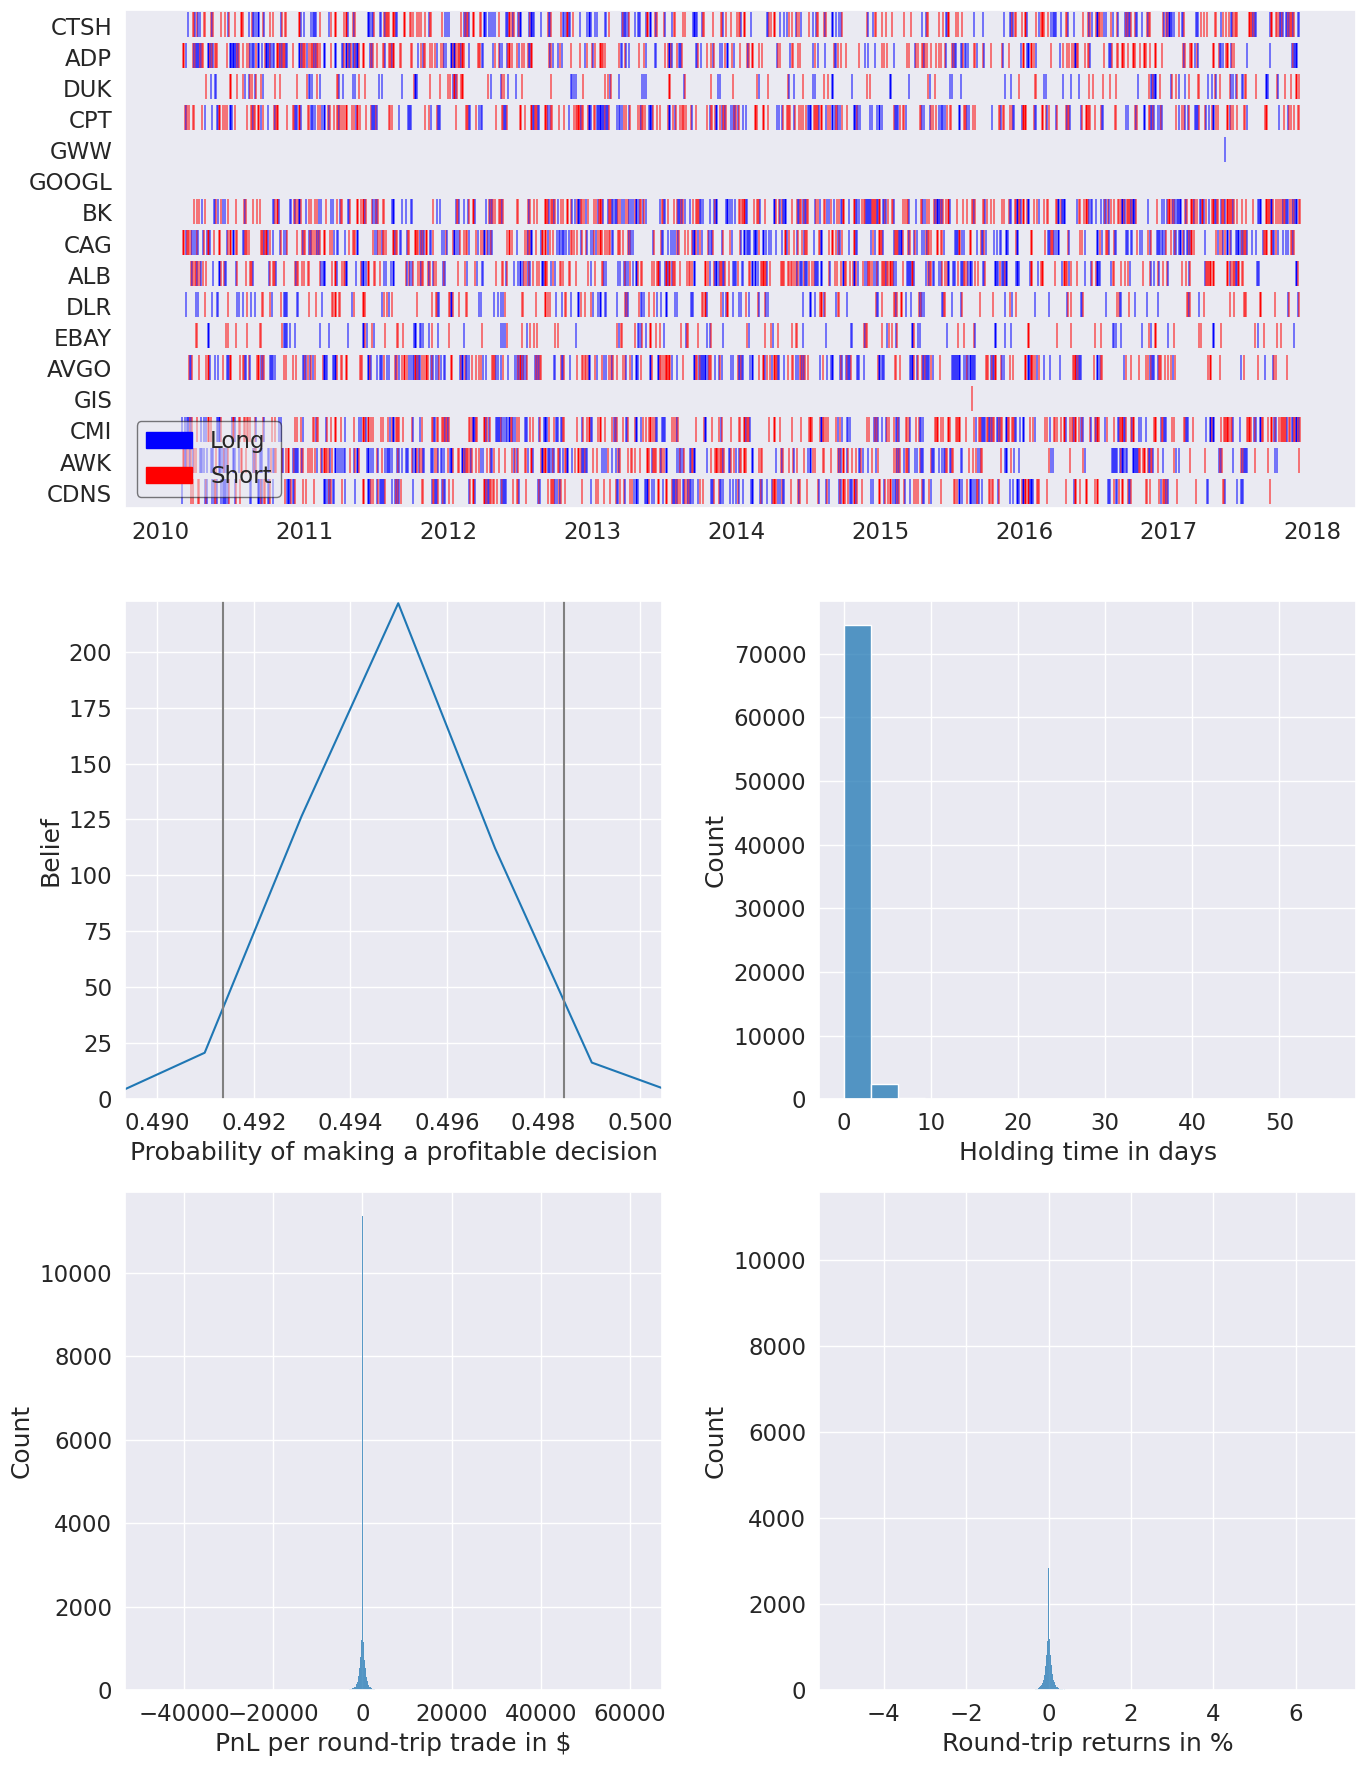

In [22]:
pf.create_full_tear_sheet(
    returns,
    positions=positions,
    transactions=transactions,
    benchmark_rets=benchmark_data,
    live_start_date=LIVE_DATE,
    round_trips=True
)